# Posthoc Analysis of Best Optuna Trial

This notebook analyzes the best hierarchical VAE (h_vae) checkpoint found by Optuna.

Goals:
1. Estimate the contribution of each antenna to the h_vae encoding using occlusion sensitivity.
2. Estimate the contribution of each Gaussian mixture branch using posterior responsibilities and reconstruction fidelity.

## Setup

In [13]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots  # noqa: F401
import torch
import torch.nn.functional as func
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

from charl_tre import dataset, util
from charl_tre.models import hierarchical
from charl_tre.models.classifier import Classifier
from charl_tre.settings import Settings

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300, "svg.fonttype": "none"})

settings = Settings()

STUDY_DIR = Path("../out") / settings.study_name
PLOTS_DIR = STUDY_DIR / "plots"
DATASET_DIR = Path("../") / settings.dataset_path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPS = 1e-8

PLOTS_DIR.mkdir(exist_ok=True)

util.init_rng(settings.seed)

### Load Models

In [14]:
# Get best trial parameters
best_trial_path = util.get_best_model_path(STUDY_DIR)
with (best_trial_path / "results.json").open("r") as f:
    trial_info = json.load(f)

params = trial_info["params"]

# Load hierarchical VAE weights
h_vae = hierarchical.Fusion(
    window_size=settings.vae_window_size,
    n_subcarriers=settings.n_subcarriers,
    n_dirichlet_components=int(params["n_components"]),
    n_mixtures=int(params["n_mixtures"]),
    n_fusion_layers=int(params["n_fusion_layers"]),
    fusion_dropout=float(params["fusion_dropout"]),
    n_antennas=settings.n_antennas,
).to(DEVICE)
state_dict = torch.load(best_trial_path / "h_vae.pt", map_location=DEVICE)
h_vae.load_state_dict(state_dict)
h_vae.to(DEVICE)
h_vae.eval()

# Load classifier weights
classifier_model = Classifier(
    antennas=[h_vae],
    n_components=params["n_components"] * params["n_mixtures"],
    n_activities=settings.n_activities,
    sample_window_size=settings.vae_window_size,
    overlap_size=settings.overlap_size,
    n_layers=1,
    dropout=0,
).to(DEVICE)
classifier_model_weights = torch.load(best_trial_path / "classifier.pt", weights_only=True)
classifier_model.load_state_dict(classifier_model_weights, strict=True)
classifier_model.eval()

print(f"Best trial path: {best_trial_path}")
print(f"Objective score: {trial_info['objective_score']:.4f}")
print(f"n_components={params['n_components']}, n_mixtures={params['n_mixtures']}, batch_size={params['batch_size']}")

Best trial path: ../out/hvae_vw75_cw450/trial_77
Objective score: 0.9603
n_components=32, n_mixtures=4, batch_size=64


### Load Datasets

In [15]:
# Datasets for h_vae latent-space analyses (window=vae_window_size)
train_ds_vae, val_ds_vae, test_ds_vae = dataset.load(
    dataset_path=DATASET_DIR,
    window_size=settings.vae_window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
test_dl_vae = util.make_dl(
    test_ds_vae,
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)
full_dl_vae = util.make_dl(
    torch.utils.data.ConcatDataset([train_ds_vae, val_ds_vae, test_ds_vae]),
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)

# Dataset for classifier evaluation (window=classifier_window_size)
_, _, test_ds_cls = dataset.load(
    dataset_path=DATASET_DIR,
    window_size=settings.classifier_window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
test_dl_cls = util.make_dl(
    test_ds_cls,
    batch_size=int(params["batch_size"]),
    shuffle=False,
    num_workers=0,
    seed=settings.seed,
)

print(f"VAE test windows: {len(test_ds_vae)}, Classifier test windows: {len(test_ds_cls)}")

VAE test windows: 1128, Classifier test windows: 948


## t-SNE Analyses

In [16]:
global_alphas_list: list[torch.Tensor] = []
mixtures_alphas_list: list[torch.Tensor] = []
labels_list: list[torch.Tensor] = []

for x, y in full_dl_vae:
    with torch.no_grad():
        _, mix_logits, alpha, *_ = h_vae(x.float().to(DEVICE))

    # alpha: (B, M, C), mix_probs: (B, M)
    mix_probs = func.softmax(mix_logits, dim=-1)

    # Mixture-aware sample embedding: flatten weighted alpha and mixture probs.
    # Shape becomes (B, n_mixtures*n_components + n_mixtures), i.e. one latent vector per sample.
    weighted_alpha = alpha * mix_probs.unsqueeze(-1)
    latent_vec = torch.cat(
        [weighted_alpha.reshape(weighted_alpha.shape[0], -1), mix_probs],
        dim=-1,
    )

    global_alphas_list.append(latent_vec.cpu())
    mixtures_alphas_list.append(alpha.cpu())
    labels_list.append(y.cpu())

global_alphas = torch.cat(global_alphas_list, dim=0)
mixtures_alphas = torch.cat(mixtures_alphas_list, dim=0)
labels = torch.cat(labels_list, dim=0)

### Global t-SNE

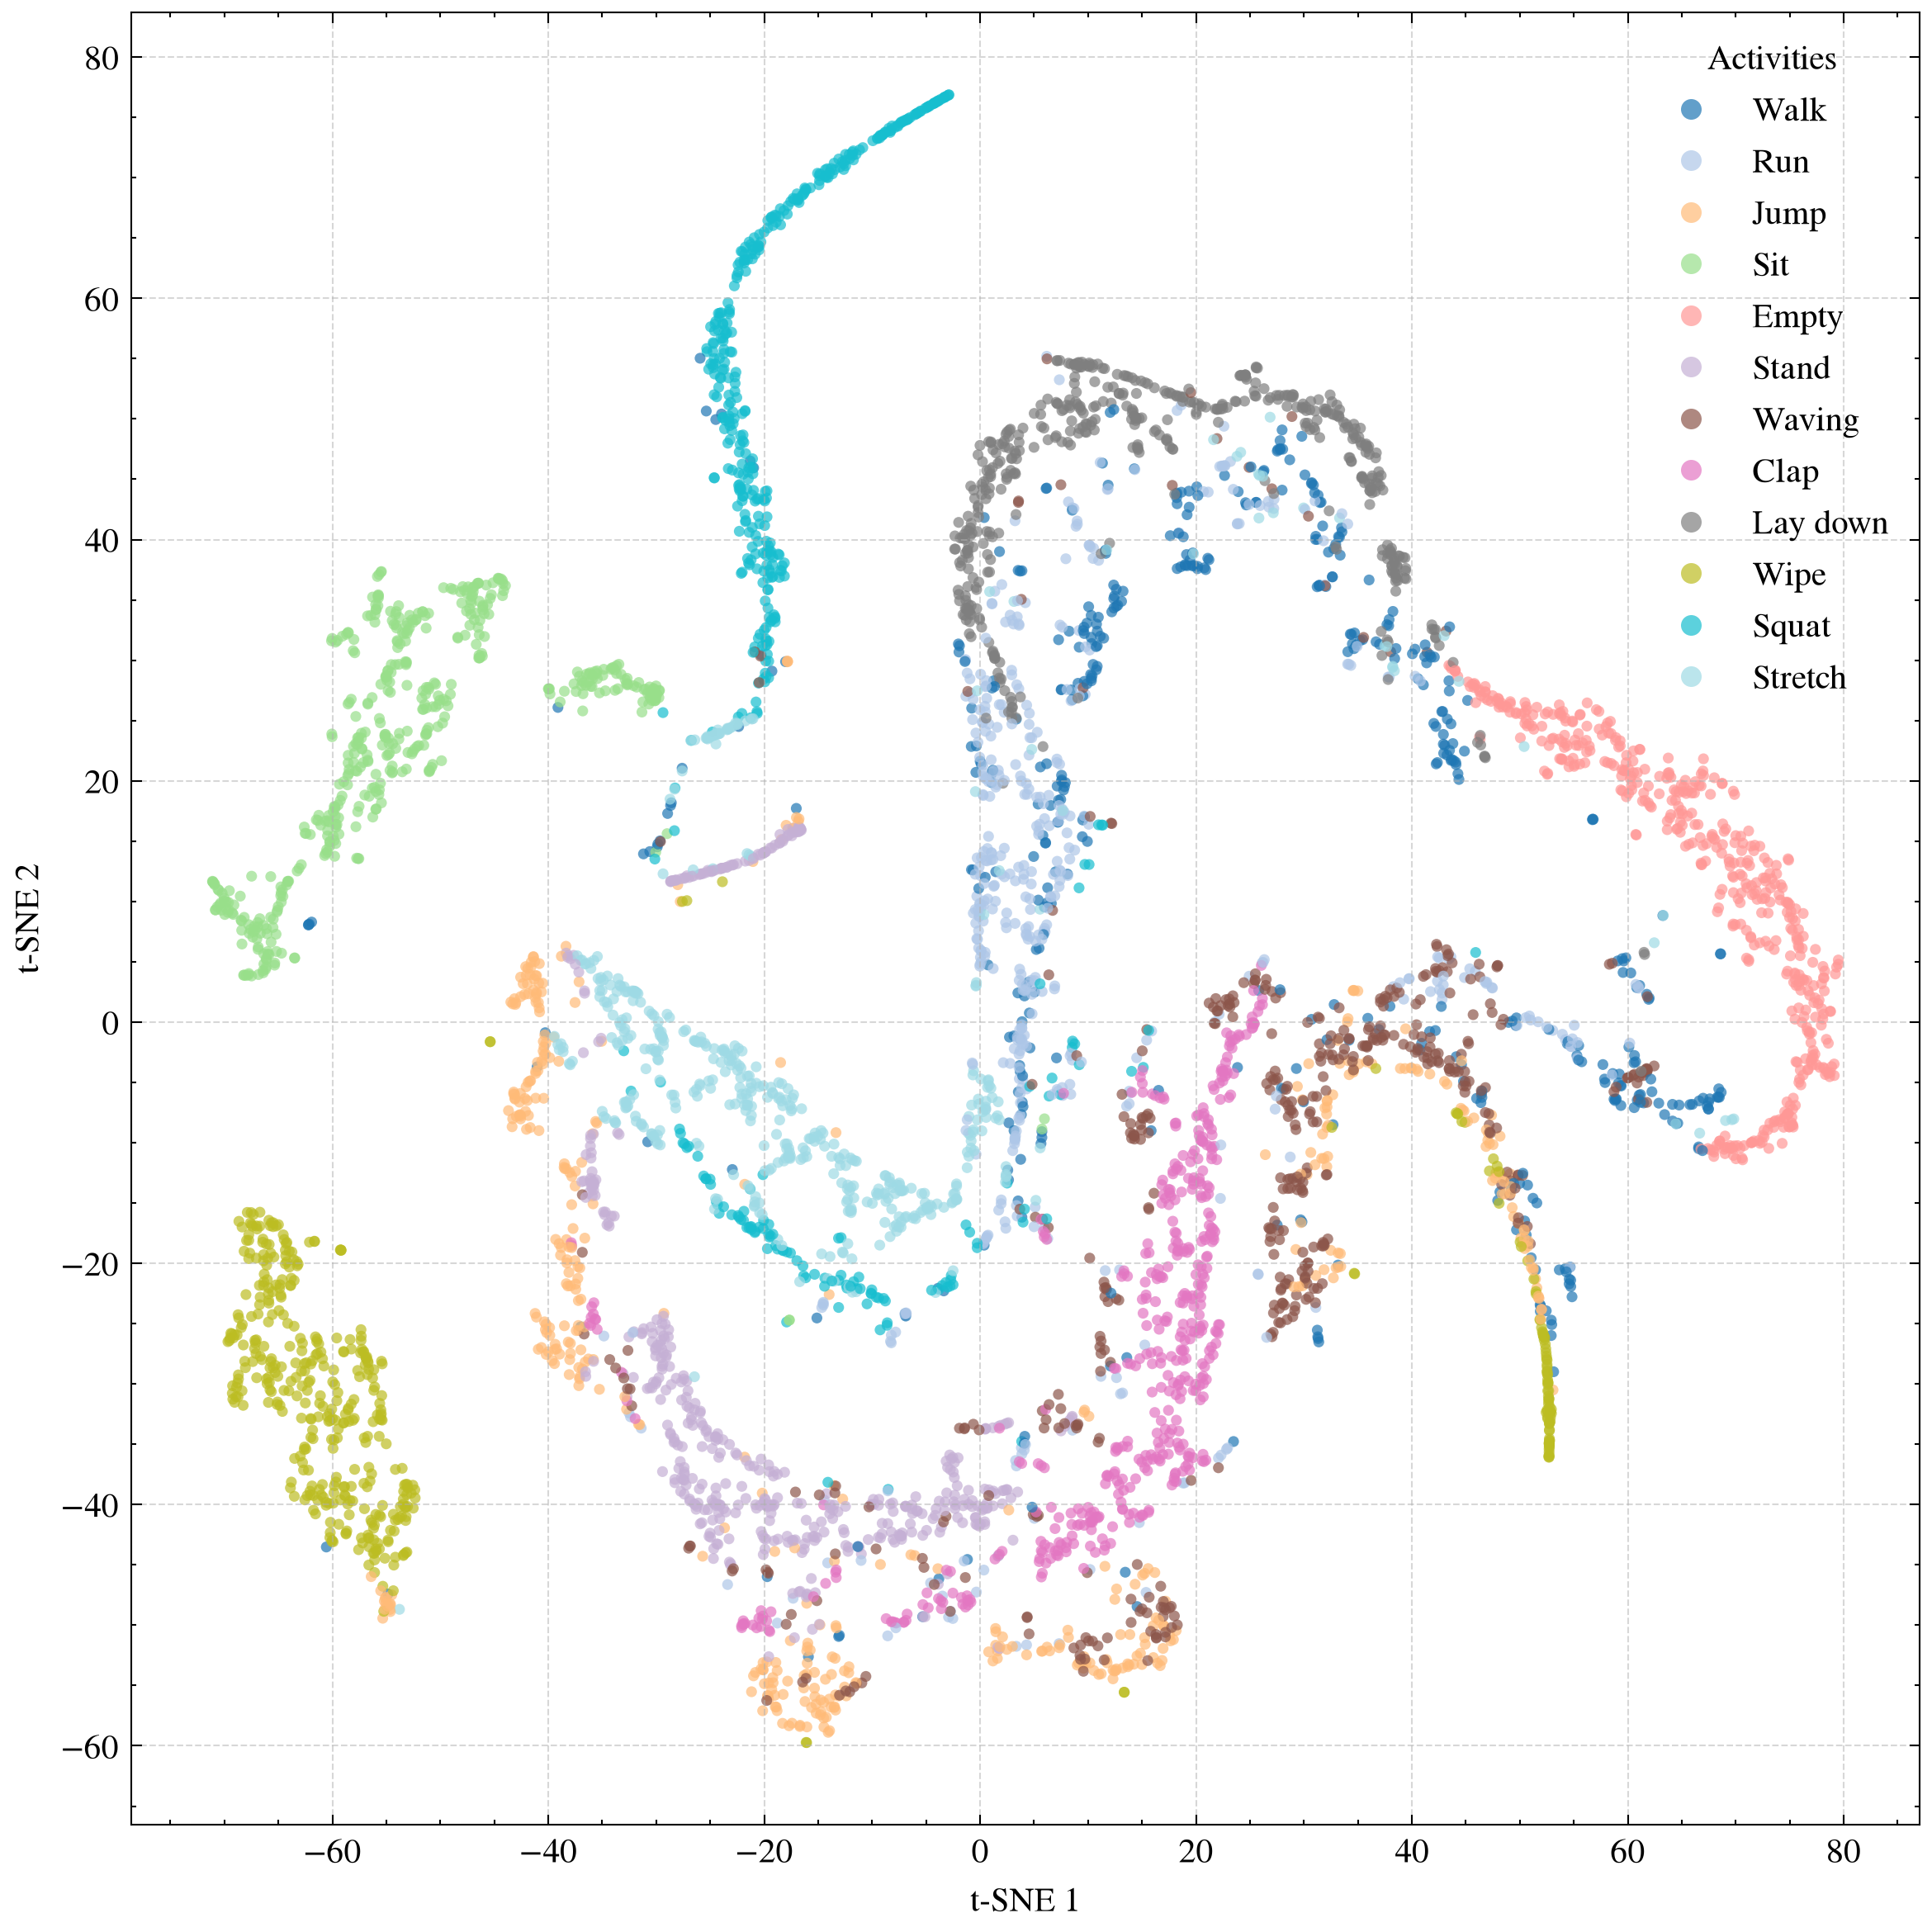

In [17]:
tsne = TSNE(
    n_components=2,
    random_state=settings.seed,
    perplexity=30,
    early_exaggeration=20,
)
emb = tsne.fit_transform(global_alphas.numpy())

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    emb[:, 0],
    emb[:, 1],
    c=labels,
    cmap="tab20",
    alpha=0.7,
    s=10,
    linewidths=0,
    vmin=0,
    vmax=len(settings.activities) - 1,
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linestyle="--", alpha=0.5)

handles, _ = scatter.legend_elements(prop="colors", num=len(settings.activities))
plt.legend(
    handles,
    settings.activities,
    title="Activities",
)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "tsne_global.pdf", bbox_inches="tight")
plt.show()

### Mixtures t-SNE

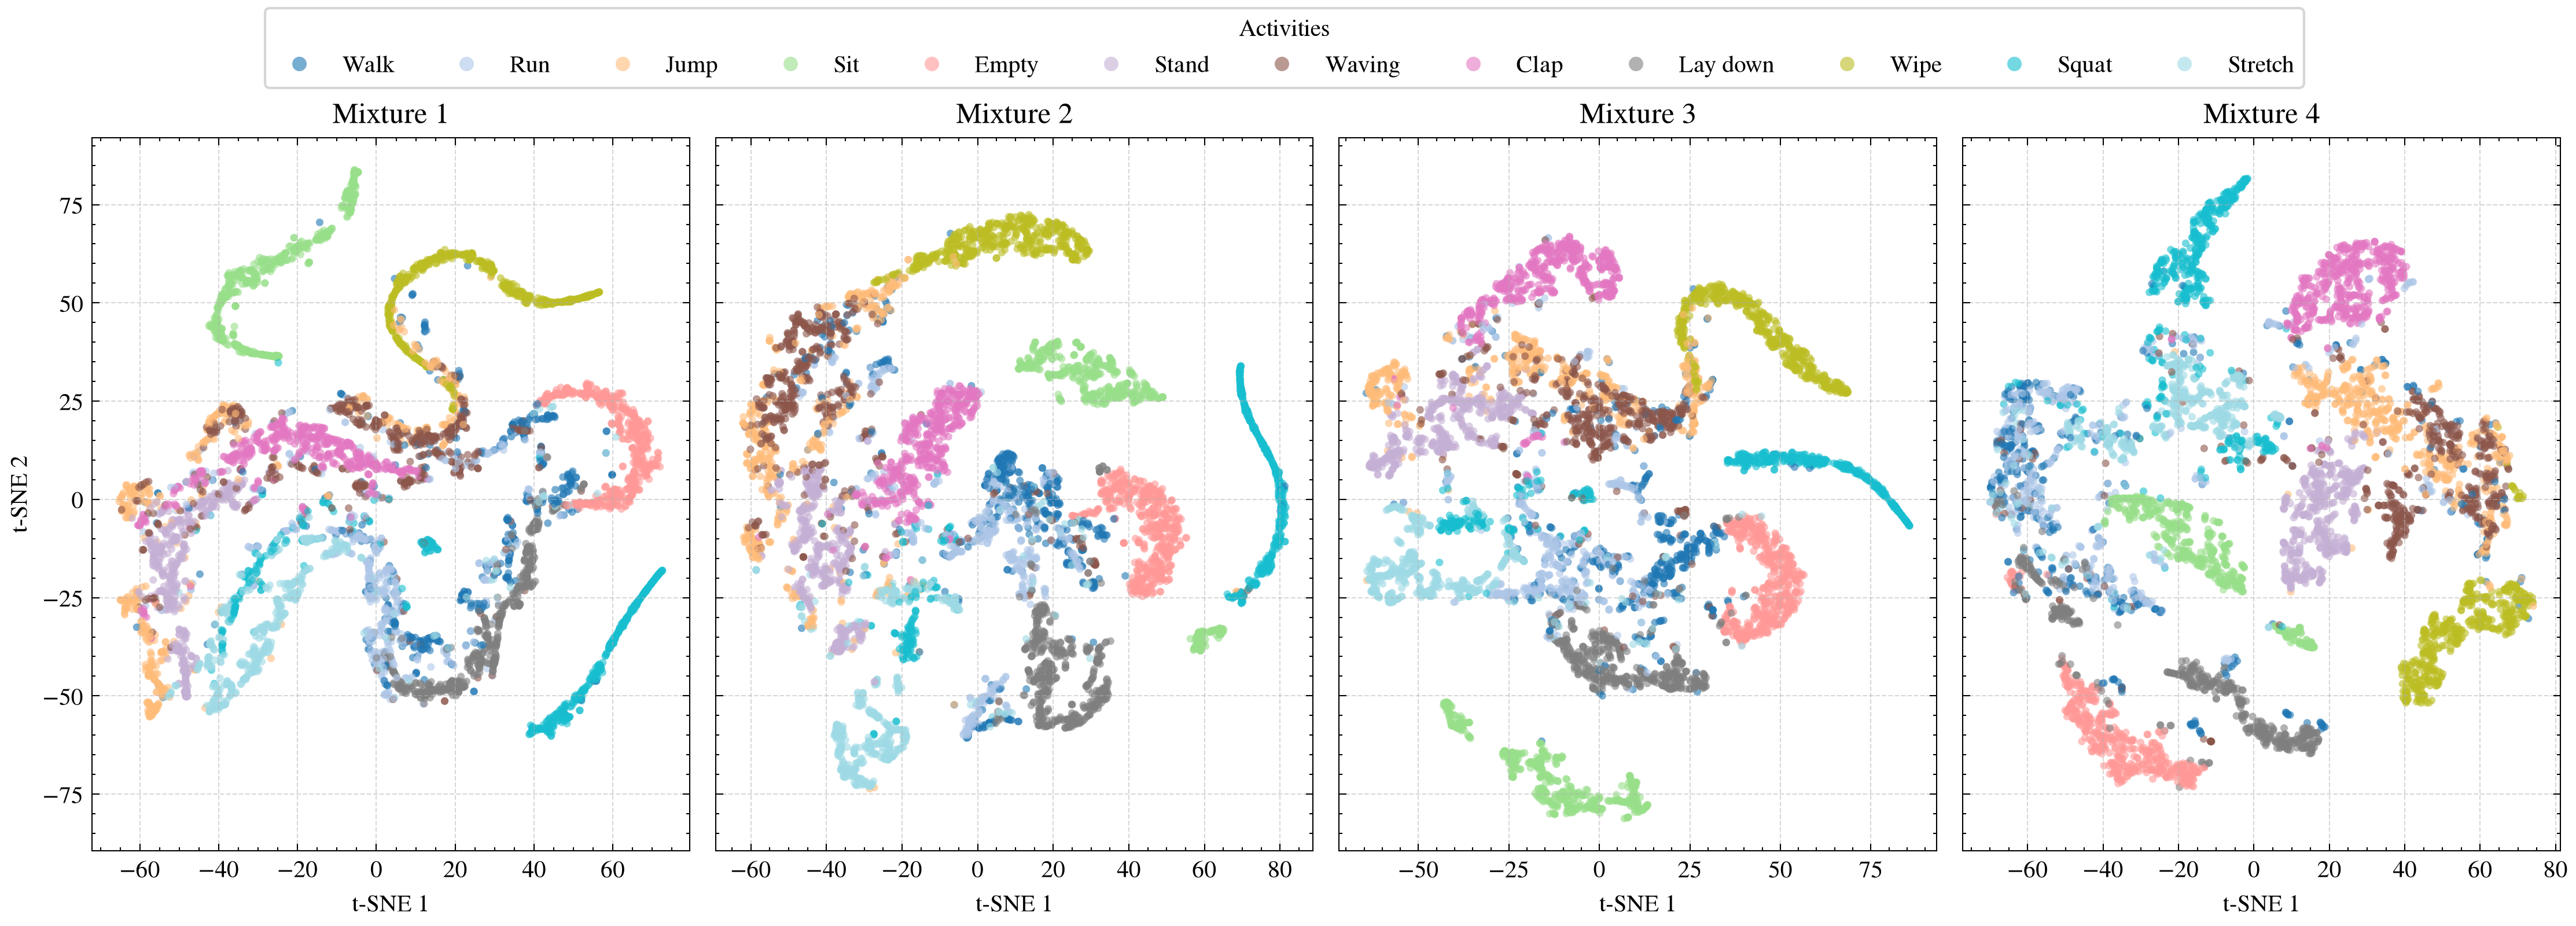

In [18]:
fig, axes = plt.subplots(1, mixtures_alphas.shape[1], figsize=(15, 5), sharey=True)
axes = np.array(axes).ravel()

for m_i in range(mixtures_alphas.shape[1]):
    ax = axes[m_i]
    m_latents = mixtures_alphas[:, m_i, :]

    tsne = TSNE(
        n_components=2,
        random_state=settings.seed,
        perplexity=30,
    ).fit_transform(m_latents.numpy())

    last_scatter = ax.scatter(
        tsne[:, 0],
        tsne[:, 1],
        c=labels,
        cmap="tab20",
        alpha=0.6,
        edgecolor="w",
        s=10,
        linewidths=0,
        vmin=0,
        vmax=len(settings.activities) - 1,
    )

    ax.set_title(f"Mixture {m_i + 1}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2" if m_i == 0 else "")
    ax.grid(True, linestyle="--", alpha=0.5)

handles, _ = last_scatter.legend_elements(prop="colors", num=len(settings.activities))  # pyright: ignore[reportPossiblyUnboundVariable]
fig.legend(
    handles,
    settings.activities,
    title="Activities",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(settings.activities),
    frameon=True,
    borderaxespad=0.1,
)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "tsne_mixtures.pdf", bbox_inches="tight")
plt.show()

## Confusion Matrix

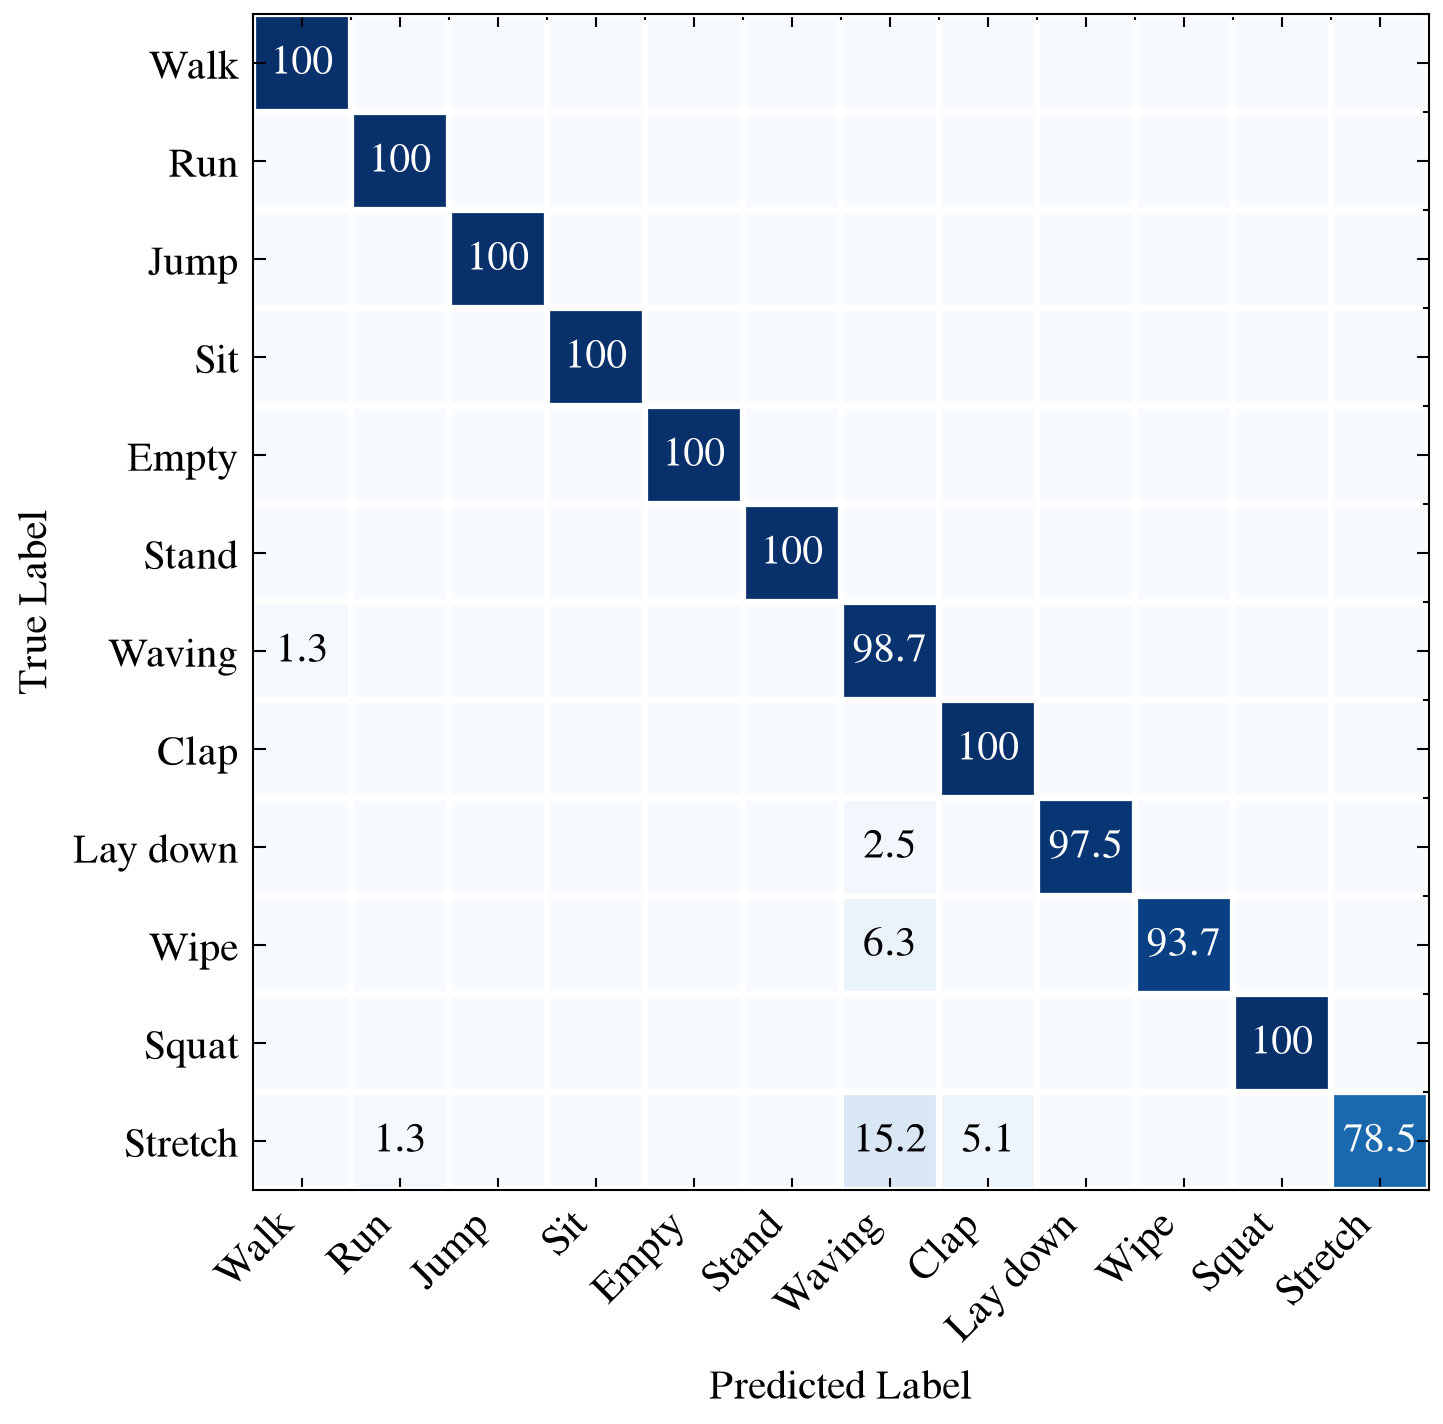

In [19]:
@torch.no_grad()
def plot_confusion_matrix(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    activities: list[str],
    name: str,
    device: torch.device,
    figsize: tuple[int, int] = (5, 5),
) -> None:
    """Plot a row-normalized confusion matrix for a classifier."""
    y_preds: list[np.ndarray] = []
    y_trues: list[np.ndarray] = []

    for x, y in dataloader:
        logits = model(x.to(device, dtype=torch.float32))
        y_preds.append(logits.cpu().numpy())
        y_trues.append(y.numpy())

    cm = confusion_matrix(
        np.concatenate(y_trues),
        np.concatenate(y_preds).argmax(axis=1),
    )

    plt.figure(figsize=figsize)
    matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)
    plt.imshow(matrix_perc, cmap="Blues")

    thresh = matrix_perc.max() / 2
    for i in range(len(activities)):
        for j in range(len(activities)):
            if cm[i, j] == 0:
                continue

            color = "white" if matrix_perc[i, j] > thresh else "black"
            text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
            plt.text(j, i, text, ha="center", va="center", color=color)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right", ticks=np.arange(len(activities)), labels=activities)
    plt.yticks(rotation=0, ticks=np.arange(len(activities)), labels=activities)

    ax = plt.gca()
    ax.set_xticks(np.arange(-0.5, len(activities)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(activities)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / name, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(classifier_model, test_dl_cls, settings.activities, "confusion_matrix.pdf", DEVICE)

## Occlusion Analysis

In [20]:
def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Compute the Jensen-Shannon divergence between two probability distributions.

    Arguments:
        p (torch.Tensor): A tensor of shape (B, N) representing the first probability distribution.
        q (torch.Tensor): A tensor of shape (B, N) representing the second probability distribution.
        eps (float): A small value to avoid division by zero and log of zero.

    Returns:
        torch.Tensor: A tensor of shape (B,) containing
            the Jensen-Shannon divergence for each pair of distributions.

    """
    p = torch.clamp(p, min=eps)
    q = torch.clamp(q, min=eps)
    p = p / p.sum(dim=-1, keepdim=True)
    q = q / q.sum(dim=-1, keepdim=True)
    m = 0.5 * (p + q)
    kl_pm = (p * (torch.log(p) - torch.log(m))).sum(dim=-1)
    kl_qm = (q * (torch.log(q) - torch.log(m))).sum(dim=-1)
    return 0.5 * (kl_pm + kl_qm)

In [21]:
antenna_js = {i: [] for i in range(settings.n_antennas)}
antenna_alpha_l1 = {i: [] for i in range(settings.n_antennas)}
mix_probs_ref_list = []
per_mix_mse_ref_list = []

for x, _ in full_dl_vae:
    xs = x.float().to(DEVICE)

    with torch.no_grad():
        # recon_ref -> (B, n_antennas, n_mixtures, window_size, n_subcarriers)
        # mix_logits_ref -> (B, n_antennas, n_mixtures)
        # alpha_ref -> (B, n_antennas, n_mixtures, n_components)
        recon_ref, mix_logits_ref, alpha_ref, *_ = h_vae(xs)

        # Get the mixture probabilities for the reference reconstruction
        mix_probs_ref = func.softmax(mix_logits_ref, dim=-1)  # (B, n_antennas, n_mixtures)
        mix_probs_ref_list.append(mix_probs_ref.cpu())

        # Handle both possible recon layouts:
        # (B, n_antennas, n_mixtures, W, S) or (B, n_mixtures, n_antennas, W, S)
        if recon_ref.shape[1] == settings.n_antennas:
            target = xs.unsqueeze(2)  # (B, n_antennas, 1, W, S)
        elif recon_ref.shape[2] == settings.n_antennas:
            target = xs.unsqueeze(1)  # (B, 1, n_antennas, W, S)
        else:
            raise RuntimeError(f"Unexpected recon_ref shape: {tuple(recon_ref.shape)}")

        per_mix_mse_ref = ((recon_ref - target) ** 2).mean(dim=(-1, -2))

        # Normalize to (B, n_antennas, n_mixtures)
        if per_mix_mse_ref.shape[1] != settings.n_antennas and per_mix_mse_ref.shape[2] == settings.n_antennas:
            per_mix_mse_ref = per_mix_mse_ref.transpose(1, 2)
        per_mix_mse_ref_list.append(per_mix_mse_ref.cpu())

    for antenna_idx in range(settings.n_antennas):
        xs_occ = xs.clone()
        xs_occ[:, antenna_idx] = (
            torch.randn_like(xs_occ[:, antenna_idx]) * xs_occ[:, antenna_idx].std() + xs_occ[:, antenna_idx].mean()
        )
        with torch.no_grad():
            recon_occ, mix_logits_occ, alpha_occ, *_ = h_vae(xs_occ)
            mix_probs_occ = func.softmax(mix_logits_occ, dim=-1)

        antenna_js[antenna_idx].append(js_divergence(mix_probs_ref, mix_probs_occ).cpu())
        antenna_alpha_l1[antenna_idx].append((alpha_occ - alpha_ref).abs().cpu())

mix_probs_ref_all = torch.cat(mix_probs_ref_list, dim=0)
per_mix_mse_ref_all = torch.cat(per_mix_mse_ref_list, dim=0)

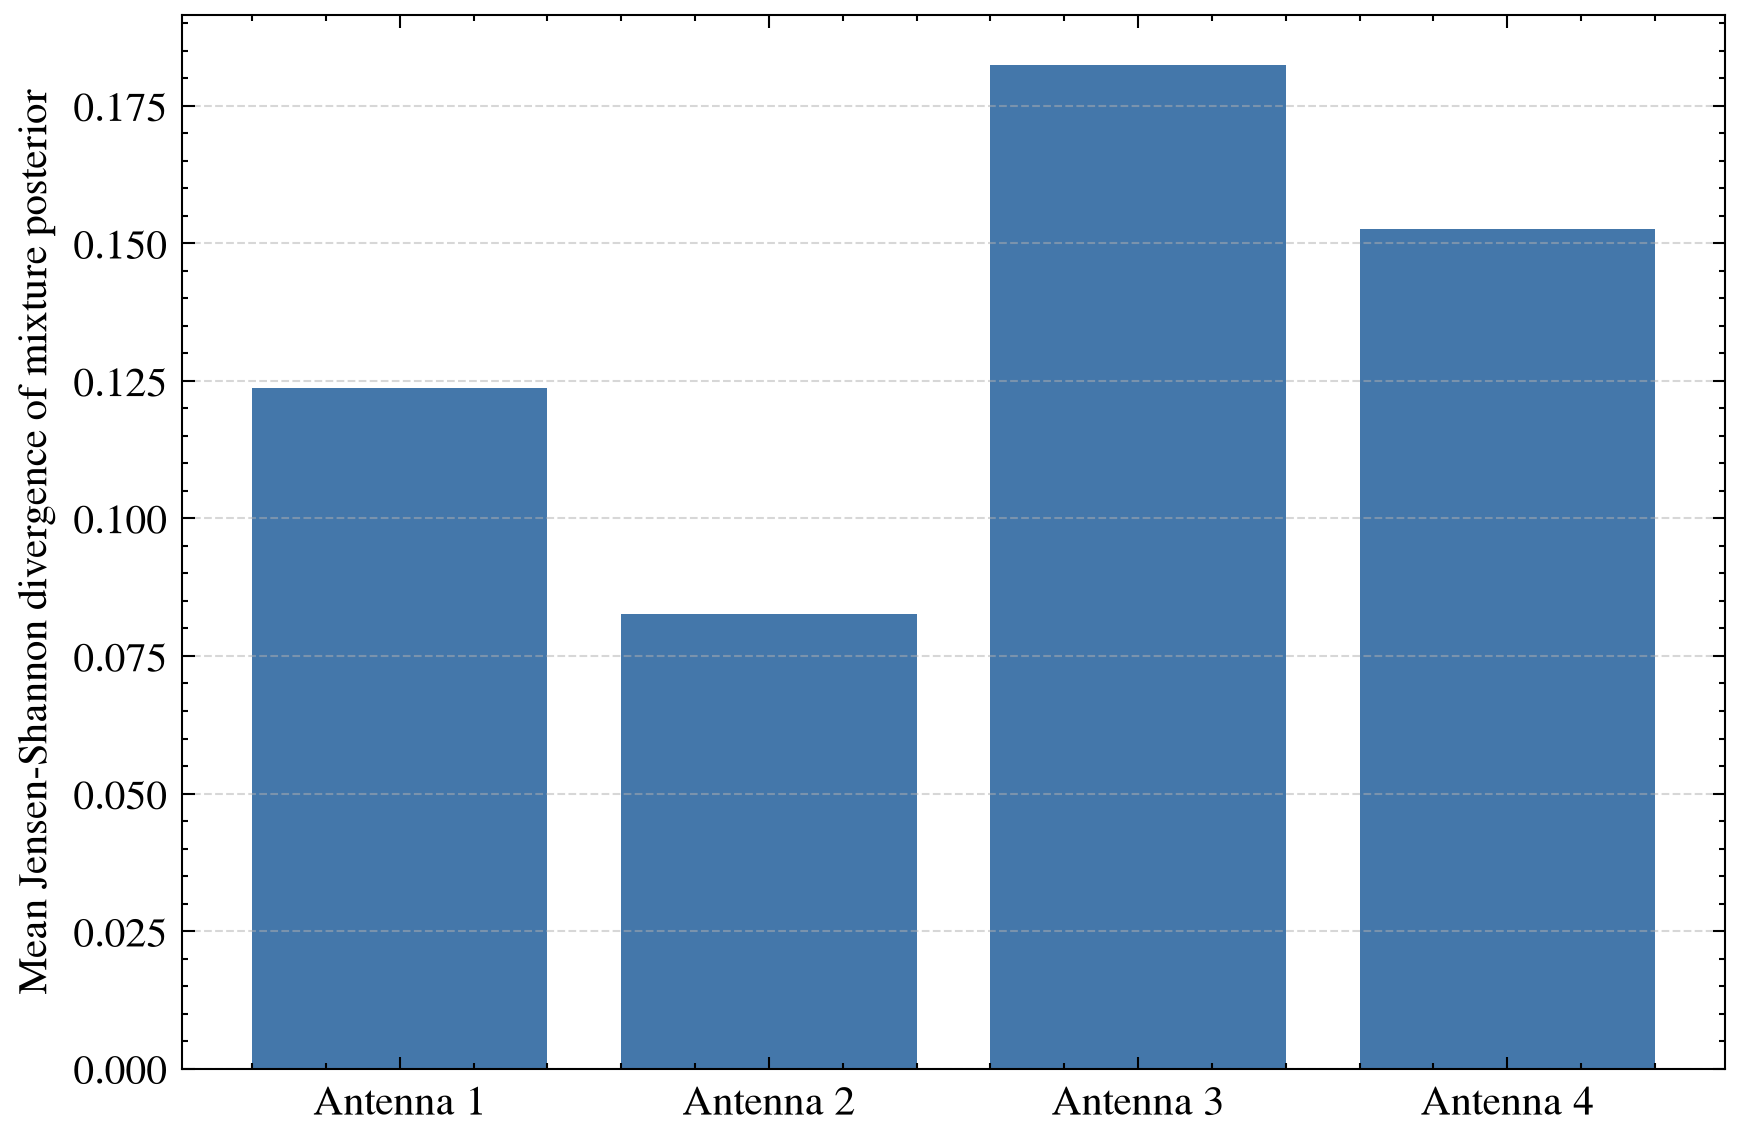

In [22]:
antenna_rows = [
    {
        "antenna": f"Antenna {antenna_idx + 1}",
        "mix_js_divergence": float(torch.cat(antenna_js[antenna_idx]).mean()),
        "delta_alpha_l1": float(torch.cat(antenna_alpha_l1[antenna_idx]).mean()),
    }
    for antenna_idx in range(settings.n_antennas)
]
plot_df = pd.DataFrame(antenna_rows)

antennas = list(plot_df["antenna"].unique())
x = np.arange(len(antennas))

plt.figure(figsize=(6, 4))
vals = plot_df["mix_js_divergence"].to_numpy()
plt.bar(x, vals)

plt.xticks(x, antennas)
plt.ylabel("Mean Jensen-Shannon divergence of mixture posterior")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "antenna_js_alpha.pdf", bbox_inches="tight")
plt.show()

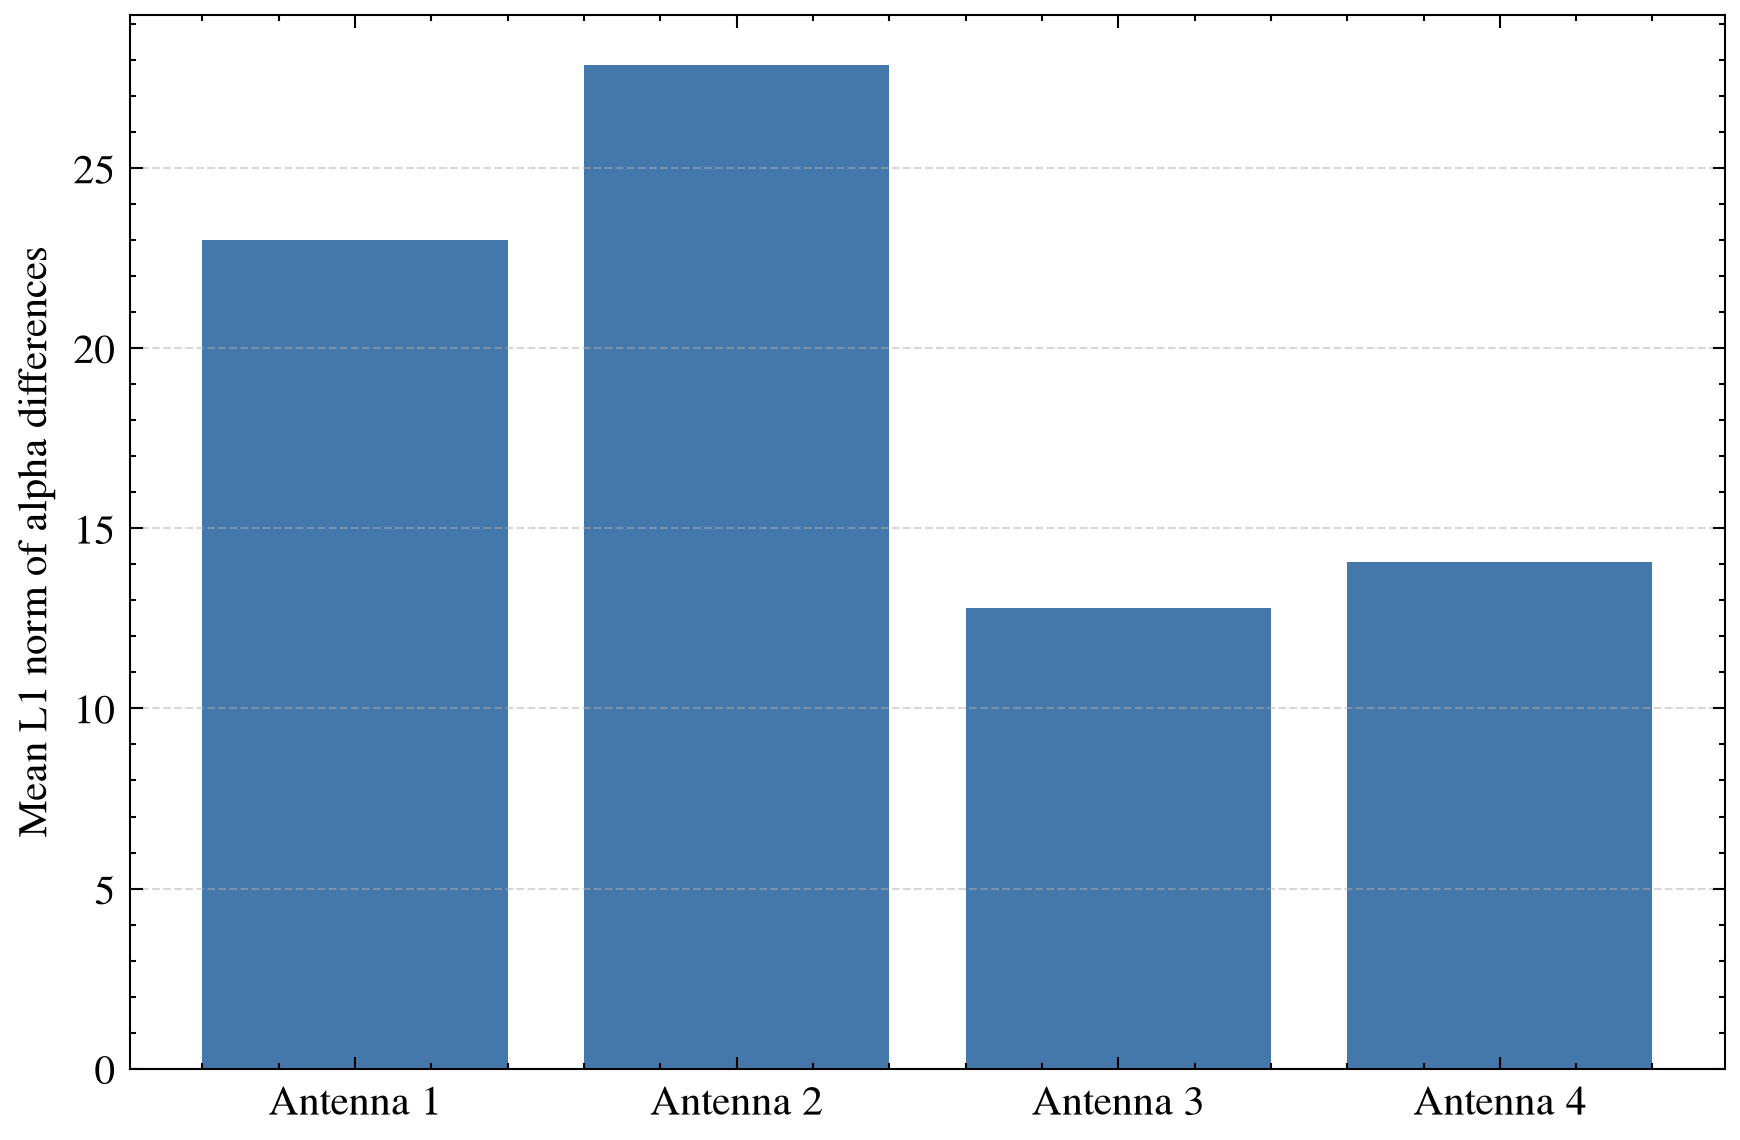

In [23]:
plt.figure(figsize=(6, 4))
vals = plot_df["delta_alpha_l1"].to_numpy()
plt.bar(x, vals)

plt.xticks(x, antennas)
plt.ylabel("Mean L1 norm of alpha differences")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "antenna_delta_alpha_l1.pdf", bbox_inches="tight")
plt.show()

### Mixture Usage

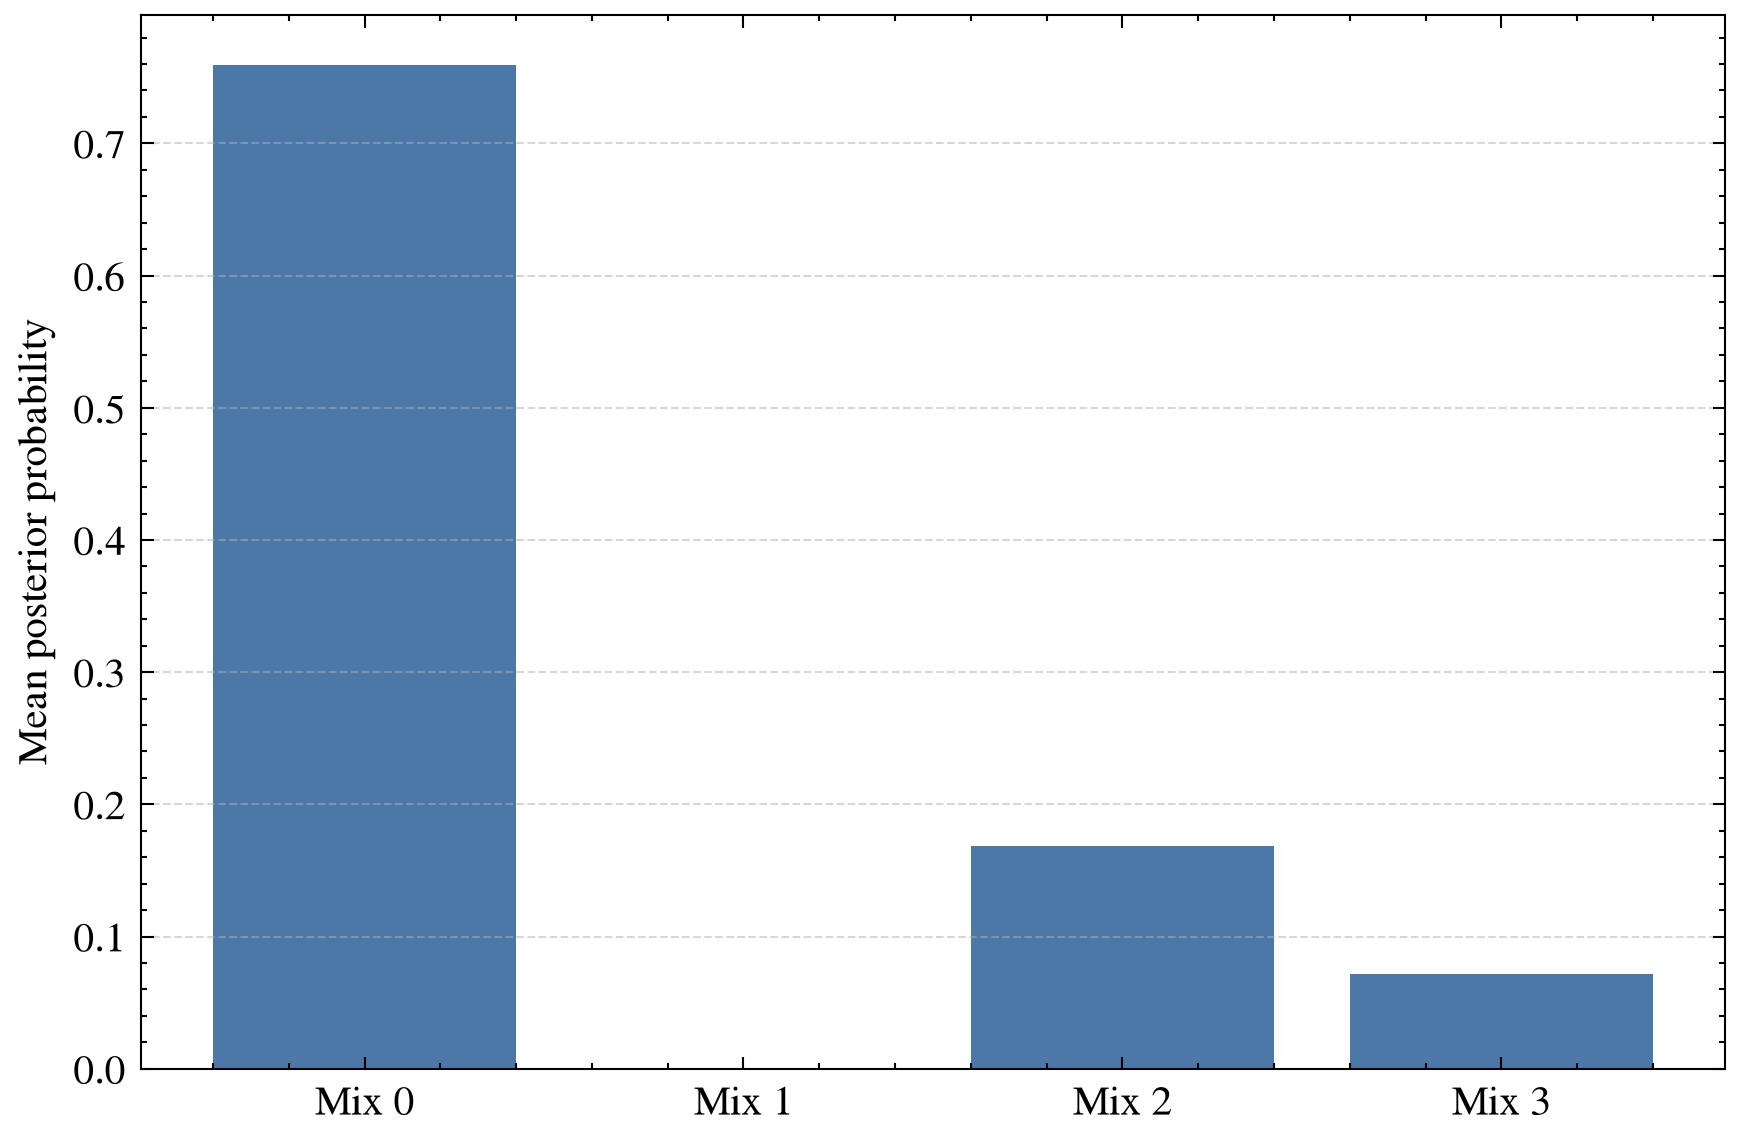

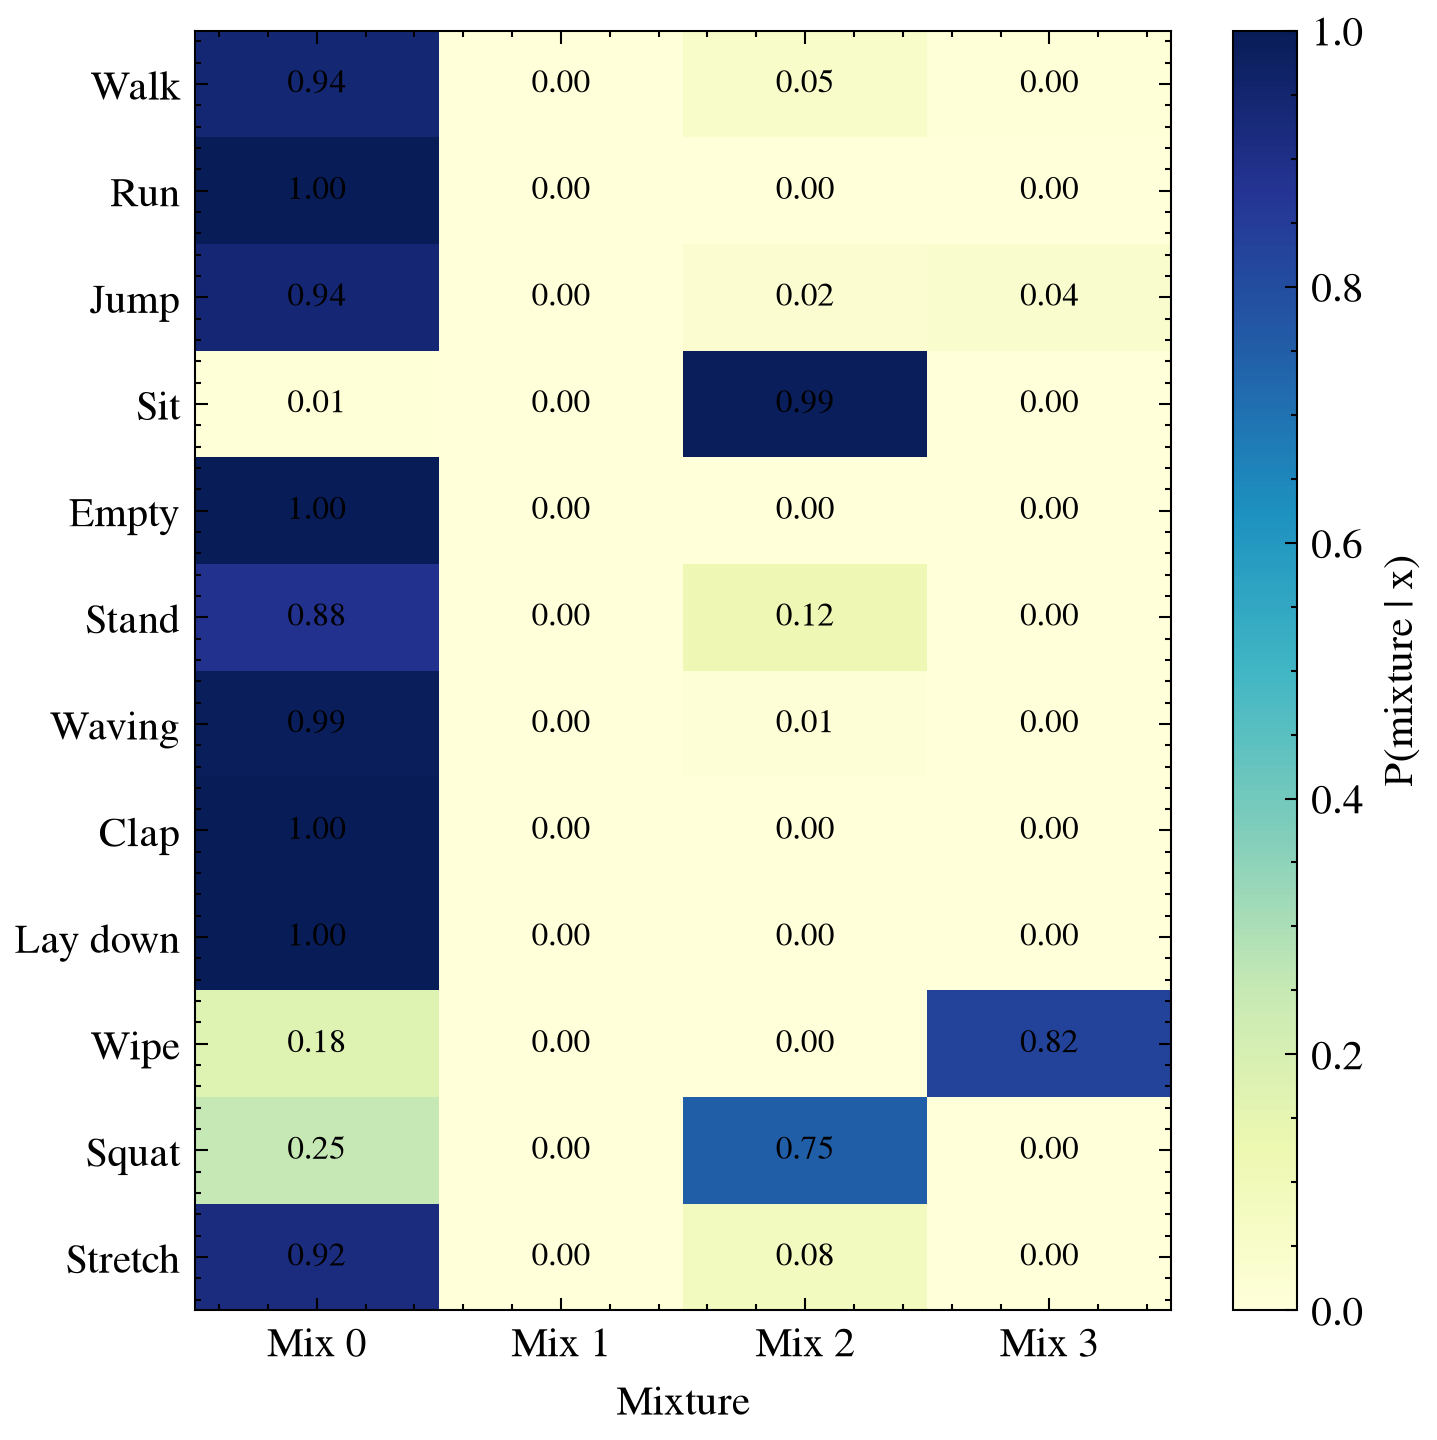

In [24]:
# Mixture-level contribution metrics from the reference forward pass.
mix_usage = mix_probs_ref_all.mean(dim=0).numpy()

mix_df = pd.DataFrame(
    {
        "mixture": [f"Mix {i}" for i in range(mix_probs_ref.shape[1])],
        "mean_posterior_prob": mix_usage,
    },
)

# Activity-conditioned posterior usage of each mixture.
activity_names = settings.activities[: settings.n_activities]
activity_ids = labels.cpu().numpy()
all_mixtures = [f"Mix {i}" for i in range(mix_probs_ref_all.shape[1])]

activity_mix = []
for activity_idx, activity_name in enumerate(activity_names):
    idx = np.where(activity_ids == activity_idx)[0]
    probs_mean = mix_probs_ref_all[idx].mean(dim=0).cpu().numpy() if len(idx) > 0 else np.zeros(len(all_mixtures))
    for mix_idx, prob in enumerate(probs_mean):
        activity_mix.append({
            "activity": activity_name,
            "mixture": f"Mix {mix_idx}",
            "mean_posterior_prob": float(prob),
        })

activity_mix_df = pd.DataFrame(activity_mix)
pivot_activity_mix = activity_mix_df.pivot_table(
    index="activity",
    columns="mixture",
    values="mean_posterior_prob",
).reindex(index=activity_names, columns=all_mixtures)


# Global mixture usage bar chart
plt.figure(figsize=(6, 4))
plt.bar(mix_df["mixture"], mix_df["mean_posterior_prob"], color="#4C78A8")
plt.ylabel("Mean posterior probability")
plt.xlabel("")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Activity per mixture heatmap
plt.figure(figsize=(5, 5))
heatmap_data = pivot_activity_mix.to_numpy()
im = plt.imshow(heatmap_data, cmap="YlGnBu", aspect="auto", vmin=0, vmax=heatmap_data.max())
plt.xticks(np.arange(len(all_mixtures)))
plt.yticks(np.arange(len(activity_names)))
plt.xticks(np.arange(len(all_mixtures)), all_mixtures)
plt.yticks(np.arange(len(activity_names)), activity_names)

for row in range(heatmap_data.shape[0]):
    for col in range(heatmap_data.shape[1]):
        plt.text(col, row, f"{heatmap_data[row, col]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, label="P(mixture | x)")
plt.xlabel("Mixture")
plt.ylabel("")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "activity_per_mixture_heatmap.pdf", bbox_inches="tight")
plt.show()